# Droplet Finding with Simulated ePix10k Data

Author: Dhruv Sharma (SLAC National Accelerator Lab, University of Illinois at Urbana-Champaign)

When an electron hits the detector surface, its deposited charge spreads across multiple pixels, or a "droplet". The size and morphology of droplets can vary significantly, and it's believed that understanding the differences in droplets better can help us differentiate between types of electron hits (single/multiple). Droplet finding is the process of isolating these clusters of lit-up pixels in detector output data for analysis, and has been applied to experimental data in the past to great success. In this notebook, we will test it on our own experimental analyses.

### 0. Import Statements

In [216]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import mplhep as mplhep
from pathlib import Path
from scipy.ndimage import gaussian_filter
import os,sys
sys.path.append('/sdf/data/lcls/ds/ued_testfac/scratch/python_packages')
from ued_LCLSII_DAQ_utilities import *

### 1. Useful Methods

Our simulation software, **Geant4**, is excellent at simulating the interaction of particles with matter and the radiation/energy depositions produced by those interactions. Our simulation thus produces a clean map of the exact energy deposits from electron hits on the detector module's surface, but without any of the additional effects of digitizing those readouts, which experimental data always has. To mimic these effects, like charge-sharing and read noise, we will use the `digitize` method below.

In [217]:
# --- constants (check ePix10k datasheet values for your gain mode) ---
W_SI      = 3.62        # eV per e-h pair
FANO      = 0.128       # Si Fano factor
DIFF_SIGMA_PIX = 0.45   # charge-sharing sigma in *pixel* units (~7 um / 100 um)
READ_NOISE_E   = 420.0   # RMS read noise in 3.12 MeV electrons (mode-dependent)
GAIN_e_per_ADU = 25.0    # set to your calibration
PEDESTAL_ADU   = 0.0
COMMON_MODE_E  = 10.0   # per-row/col offset RMS (optional)

def digitize(edep_MeV):
    # 1. energy -> mean number of electrons
    N = edep_MeV * 1e6 / W_SI

    # 2. Fano fluctuation (only where signal exists)
    sigma_fano = np.sqrt(np.maximum(FANO * N, 0.0))
    N = np.random.normal(N, sigma_fano)
    N = np.clip(N, 0, None)

    # 3. charge sharing: diffuse the charge to neighbors
    N = gaussian_filter(N, sigma=DIFF_SIGMA_PIX, mode='constant')

    # 4. common-mode (per-row offset), optional
    N += np.random.normal(0, COMMON_MODE_E, size=(N.shape[0], 1))

    # 5. electronic read noise (every pixel, even empty ones)
    N += np.random.normal(0, READ_NOISE_E*1000, size=N.shape)

    # 6. gain + pedestal + quantization -> ADU
    adu = N / GAIN_e_per_ADU + PEDESTAL_ADU
    return np.round(adu).astype(int) / (1e4)

We'll also get the simulated run from our tests with `uproot` and extract the energy deposition map, which takes the form of a 2D histogram.

In [218]:
run_num = 1
sim_file = uproot.open(f"/sdf/home/d/dhruvshr/SULI2026/ePix_Simulation/Examples/PixelSim_ePix_Data_Gen/outputs/sparse_sim_run_{run_num:03d}.root")
edep_map, xedges, yedges = sim_file['EdepMap'].to_numpy()

FileNotFoundError: [Errno 2] No such file or directory: '/sdf/home/d/dhruvshr/SULI2026/ePix_Simulation/Examples/PixelSim_ePix_Data_Gen/outputs/sparse_sim_run_001.root'

### 2. Digitizing the Simulated Edeps Data

Now let's "digitize" this data and view the difference!

In [ ]:
digi_edep_map = digitize(edep_map)

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(12,5))
ax = ax.flatten()
plots=[edep_map, digi_edep_map]

plt.suptitle(r"$\bf{Energy\ Depositions\ (Simulated\ vs\ Digitized\ }$")

for i in range(2):
    img = ax[i].imshow(plots[i],aspect='equal',cmap = 'viridis')
    ax[i].set_xlim(0,100)
    ax[i].set_ylim(0,100)
    ax[i].figure.colorbar(img, label="Energy Deposition (keV)",ax=ax[i])

ax[0].set_title("Simulated Energy Depositions")
ax[1].set_title("Digitzed Energy Depositions")

plt.tight_layout()

### 3. Running Droplet Finding

Our droplet finding algorithm works in 3 steps:

- **Eliminate Noise:** The detector output will always have a certain amount of random fluctuations caused by electronic read noise that cause even areas without electron hits to exhibit variations in "energy deposition" (though there isn't really any). To get rid of this, we apply a thresholding process, in which any pixels with intensity below `threshold` are essentially zeroed out and no longer considered.
- **Group Pixels:** What's left after the thresholding step is a large field of 0s with a few clusters of nonzero pixels in between. These are our droplet candidates, and we'll group them into clusters of directly adjacent pixels.
- **Filter Candidates:** Even with our complete set of droplet candidates, there may still be a few pixels where the noise ended up being quite significant and made it past the thresholding step. So, all the pixels in each droplet are summed up, and any droplets with a combined intensity less than `min_signal` are cut as well. What's left is our complete list of droplets!

Now run the droplet counting algorithm with the code below and see the results for yourself!

In [ ]:
# Define some trial peak finding parameters
max_electrons = 1000  # Max number of electrons the peakFinder allowed to find
threshold     = 40    # Threshold for peak finding, pixel intensity below this is filtered
min_signal    = 100   # Min intensity to be considered as electron signal

n, _x, _y, _ints, _sizes = blobCounter(digi_edep_map, threshold, min_signal)

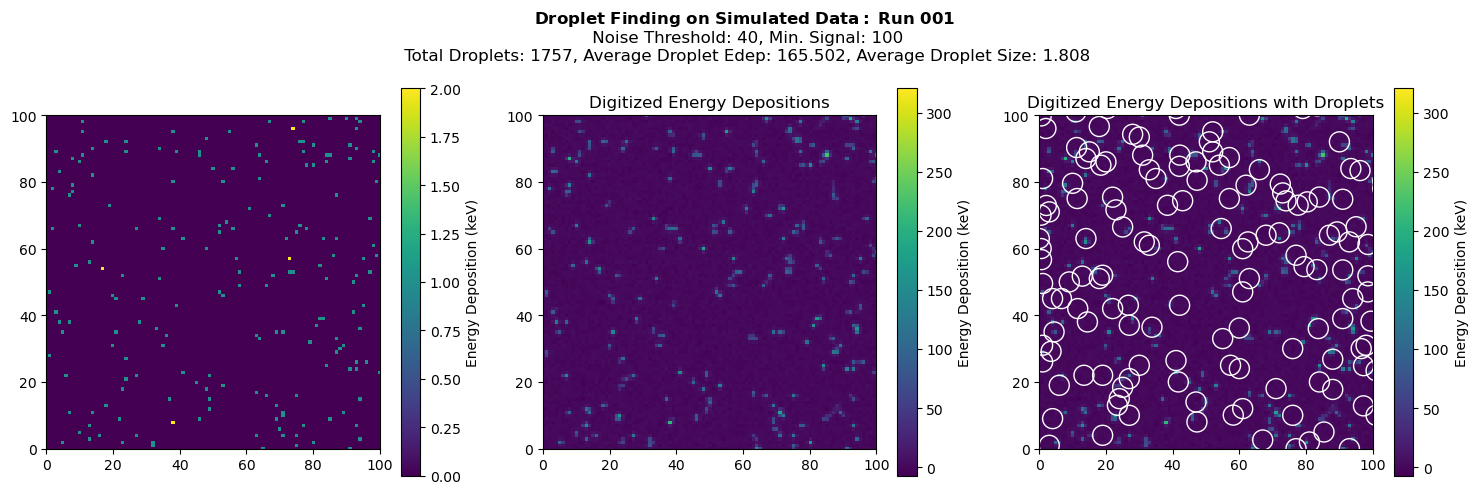

In [219]:
fig, ax = plt.subplots(1,3,figsize=(15,5))
ax = ax.flatten()
plots = [sim_file['EntryMap'].to_numpy()[0].T,digi_edep_map.T,digi_edep_map]

for i in range(3):
    img = ax[i].imshow(plots[i],aspect='equal',cmap = 'viridis')
    ax[i].set_xlim(0,100)
    ax[i].set_ylim(0,100)
    ax[i].figure.colorbar(img, label="Energy Deposition (keV)",ax=ax[i])

ax[2] = plt.gca()
ax[2].imshow(digi_edep_map.T)
for i,(x,y) in enumerate(zip(_x[:700],_y[:700])):
    ax[2].add_patch(plt.Circle((x,y),3,color='white',fill=False))

plt.suptitle(fr"$\bf{{ Droplet\ Finding\ on\ Simulated\ Data:\ Run\ {run_num:03d}}}$" + 
             f'\n Noise Threshold: {threshold}, Min. Signal: {min_signal}' +
            f'\n Total Droplets: {n}, Average Droplet Edep: {np.mean(_ints):.3f}, Average Droplet Size: {np.mean(_sizes):.3f}')
ax[1].set_title("Digitized Energy Depositions")
ax[2].set_title("Digitized Energy Depositions with Droplets")

plt.tight_layout()

### 4. Compare to Experiment

Let's compare our simulated ouptut to some experimental runs that also recorded the same data with droplet finding. To get the experimental data, we'll use the below methods:

In [220]:
def get_hist_mean(hist):
    counts, edges = hist[0], hist[1]
    bin_centers = (edges[:-1] + edges[1:]) / 2
    mean = np.average(bin_centers, weights=counts)
    return mean

def get_exp_data(run, is_sparse):
    if (is_sparse):
        exp_py = np.load('../../../ePix_Analysis/catalog/Intensity_evts_run_'+str(run)+'_sparse.npy')
    else:
        exp_py = np.load('../../../ePix_Analysis/catalog/Intensity_evts_run_'+str(run)+'_dense.npy')
    bins_intn=np.arange(80,1000,5)
    all_counts = []
    for i_mdl in range(4):
        hist_intn, bin_edges = np.histogram(exp_py[:,i_mdl,:].flatten(), bins=bins_intn)
        all_counts.append(hist_intn)
    exp_counts = np.mean(np.array(all_counts), axis=0)
    return exp_counts

In [221]:
exp_126 = get_exp_data(126,True)
exp_bins = np.linspace(80,995,184)[:-1]

The experimental runs span many events ("frames" of the detector output), so to get a relatively comparable sample size we'll aggregate findings across multiple simulations with identical settings.

In [223]:
sparse_sim_data=np.zeros(500)
sparse_sim_bins=np.linspace(0,1,501) * 1000
num_jobs = 20
num_elecs = 2000
edep_maps = []

for i in range(1,num_jobs+1):
    sim_file = uproot.open(f"/sdf/home/d/dhruvshr/SULI2026/ePix_Simulation/Examples/PixelSim_ePix_Data_Gen/outputs/sim_{num_elecs}_e-_run_{i:03d}.root")
    sparse_sim_data += sim_file["TotalEdep"].to_numpy()[0]
    edep_maps.append(sim_file["EdepMap"].to_numpy()[0])

In [224]:
digi_edep_maps = [digitize(edep_map) for edep_map in edep_maps]

In [225]:
# Define some trial peak finding parameters
max_electrons = 1000  # Max number of electrons the peakFinder allowed to find
threshold     = 40    # Threshold for peak finding, pixel intensity below this is filtered
min_signal    = 100   # Min intensity to be considered as electron signal

num_droplets = 0
xs = []
ys = []
droplet_edeps = []
droplet_sizes = []

for digi_edep_map in digi_edep_maps:
    n, x, y, edep, size = blobCounter(digi_edep_map, threshold, min_signal)
    num_droplets += n
    xs.append(x)
    ys.append(y)
    droplet_edeps += list(edep)
    droplet_sizes += list(size)

droplet_edeps = np.array(droplet_edeps)
droplet_sizes = np.array(droplet_sizes)

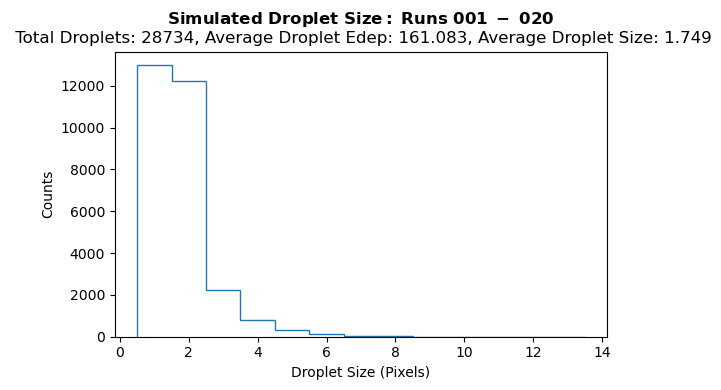

In [226]:
fig,ax = plt.subplots(1,1,figsize=(6,4))
plt.hist(droplet_sizes,bins=np.arange(min(_sizes), max(_sizes)+2) - 0.5,histtype='step')
plt.title(fr"$\bf{{Simulated\ Droplet\ Size:\ Runs\ {run_num:03d}\ -\ {num_jobs:03d}}}$" + 
          f'\n Total Droplets: {num_droplets}, Average Droplet Edep: {np.mean(droplet_edeps):.3f}, Average Droplet Size: {np.mean(droplet_sizes):.3f}')
plt.xlabel("Droplet Size (Pixels)")
plt.ylabel("Counts")
plt.tight_layout();

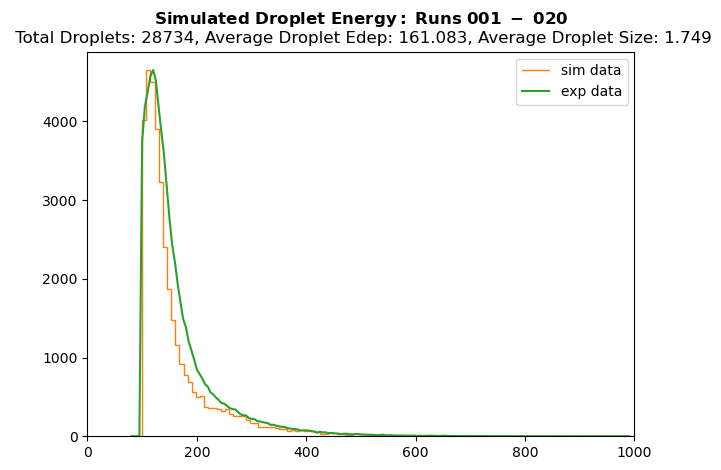

In [235]:
plt.title(fr"$\bf{{Simulated\ Droplet\ Energy:\ Runs\ {run_num:03d}\ -\ {num_jobs:03d}}}$" + 
          f'\n Total Droplets: {num_droplets}, Average Droplet Edep: {np.mean(droplet_edeps):.3f}, Average Droplet Size: {np.mean(droplet_sizes):.3f}')
ratio = 1.28
counts,bins,bars = plt.hist(droplet_edeps,bins=200)
for bar in bars: bar.remove()
plt.stairs(counts*ratio, bins,label='sim data')
plt.plot(exp_bins,exp_126,label='exp data')
plt.xlim(0,1000)
plt.legend()
plt.tight_layout();

In [271]:
detector_noise = 5
sigma_bins = detector_noise / (sparse_sim_bins[1] - sparse_sim_bins[0])  # use the actual bin width of sparse_sim_bins
conv_sparse_data = gaussian_filter1d(counts.astype(float), sigma_bins, mode='constant', cval=0)

In [272]:
scale = exp_126[np.argmax(exp_126)] / conv_sparse_data[np.argmax(conv_sparse_data)]

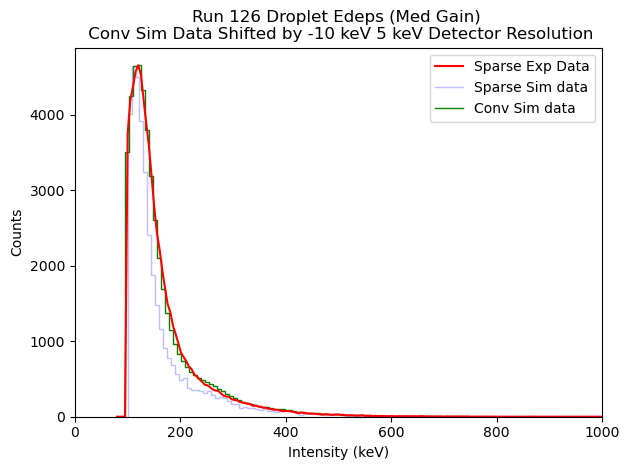

In [282]:
plt.title(f"Run 126 Droplet Edeps (Med Gain) \n Conv Sim Data Shifted by -10 keV 5 keV Detector Resolution")
plt.xlabel("Intensity (keV)")
plt.ylabel("Counts")
plt.plot(np.linspace(80,1000,183),exp_126,color='red',label='Sparse Exp Data')
plt.stairs(1.28 * counts,bins,color='blue',label='Sparse Sim data',alpha=0.25)
plt.stairs(conv_sparse_data*scale,bins-5, color='green', label='Conv Sim data')
plt.xlim(0,1000)
plt.legend()
plt.tight_layout()